In [2]:
import numpy as np,pandas as pd,matplotlib.pyplot as plt
import seaborn as ses

In [3]:
df=pd.read_csv("../datasets/fertilizer_recommendation_dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   str    
 9   Crop         3100 non-null   str    
 10  Fertilizer   3100 non-null   str    
 11  Remark       3100 non-null   str    
dtypes: float64(8), str(4)
memory usage: 290.8 KB


In [4]:
df.head()
df.isnull().sum()

Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64

In [5]:
df.describe()
df.duplicated().sum()
df.columns.unique()

Index(['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous',
       'Potassium', 'Carbon', 'Soil', 'Crop', 'Fertilizer', 'Remark'],
      dtype='str')

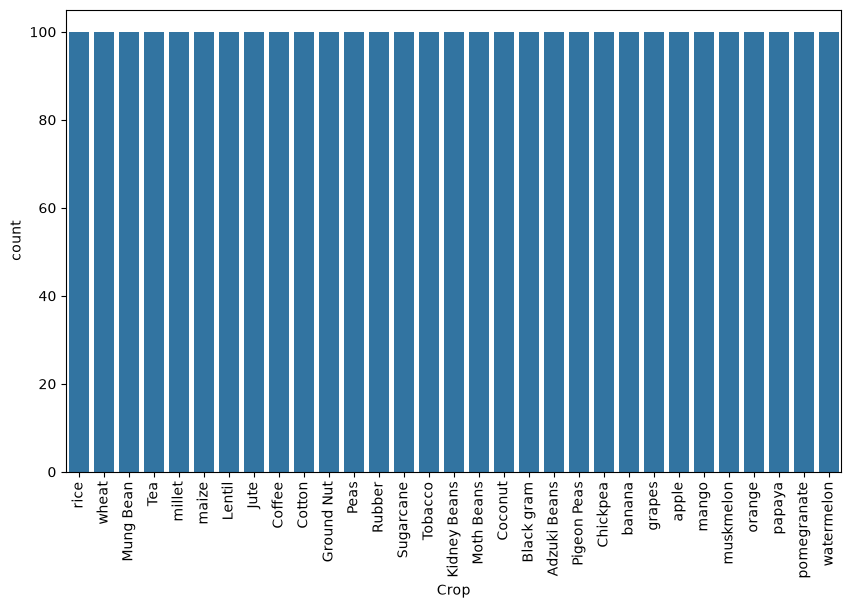

In [6]:
plt.figure(figsize=(10,6))
ses.countplot(x='Crop',data=df)
plt.xticks(rotation=90)
plt.show()

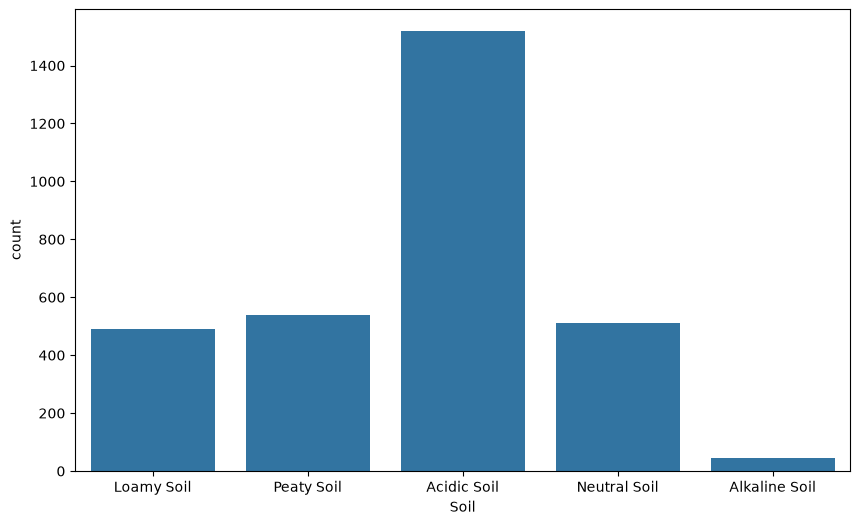

In [7]:
plt.figure(figsize=(10,6))
ses.countplot(x='Soil',data=df)
plt.show()

array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'Moisture'}>,
        <Axes: title={'center': 'Rainfall'}>],
       [<Axes: title={'center': 'PH'}>,
        <Axes: title={'center': 'Nitrogen'}>,
        <Axes: title={'center': 'Phosphorous'}>],
       [<Axes: title={'center': 'Potassium'}>,
        <Axes: title={'center': 'Carbon'}>, <Axes: >]], dtype=object)

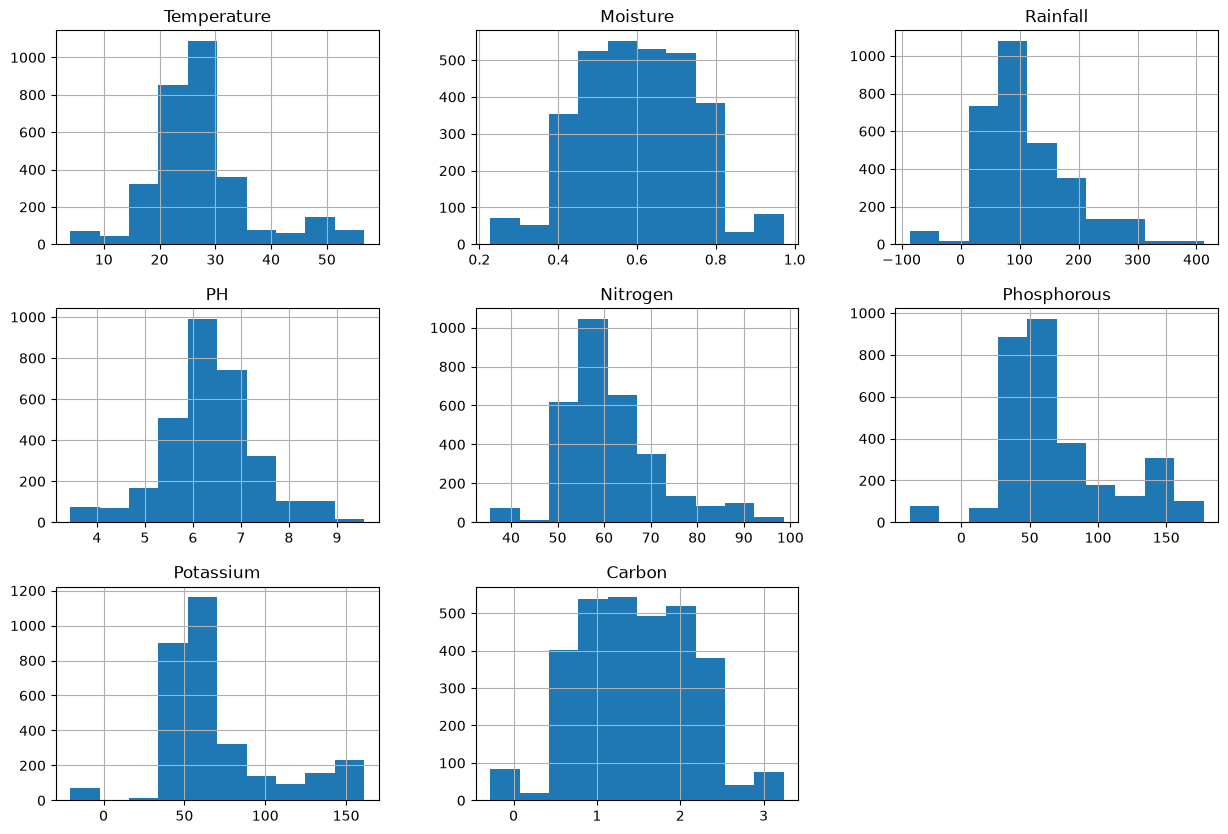

In [8]:
df.hist(figsize=(15,10))

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [11]:
encoder=LabelEncoder()
df['Soil']=encoder.fit_transform(df['Soil'])
df['Crop']=encoder.fit_transform(df['Crop'])
df['Remark']=encoder.fit_transform(df['Remark'])
df['Fertilizer']=encoder.fit_transform(df['Fertilizer'])

In [12]:
x=df.drop(['Fertilizer', 'Remark'], axis=1)
y=df['Fertilizer']

In [13]:
import pickle
from sklearn.model_selection import train_test_split

In [14]:
pickle.dump(encoder,open('../models/label_encoder_fertilizer.pkl','wb'))

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)

In [17]:
pickle.dump(scaler,open('../models/scaler_fertilizer.pkl','wb'))

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
model=RandomForestClassifier()
model.fit(x_train,y_train)
predictions=model.predict(x_test)
print("Accuracy Score:",accuracy_score(y_test,predictions))


Accuracy Score: 0.9887096774193549


In [19]:
accuracy=accuracy_score(y_test,predictions)
print("Accuracy of the model is:",accuracy)
pickle.dump(model,open('../models/fertilizer_model.pkl','wb'))

Accuracy of the model is: 0.9887096774193549


In [20]:
from sklearn.svm import SVC
model_svm=SVC()
model_svm.fit(x_train,y_train)
predictions_svm=model_svm.predict(x_test)
accuracy_svm=accuracy_score(y_test,predictions_svm)
print("Accuracy of the SVM model is:",accuracy_svm)

Accuracy of the SVM model is: 0.8
